# 📓 Pre-Workshop Notebook 4: Cleaning and Processing Research Signals
## Scientific Workflows for Brain and Behavioral Research
### National Science Foundation Supported Learning Initiative (Award No. OAC-2417875)

---

## 📋 Set Up Your Profile
*Run the cell below to record your progress.*

In [ ]:
# PROFILE SYNC
student_name = "Hari Sai Kaja"
institution = "Grand Valley State University"
active_notebook = "Notebook 04 — Signal Cleaning and Processing"

print(f"✅ Profile synced for {student_name} ({institution})")
print(f"Current notebook: {active_notebook}")

---

## 🤖 Using AI Tools to Build Your Workflow ("Ask → Build → Document")

As a **Workflow Designer** working with signal data, your main responsibility is making sure the signal you are analyzing is clean and meaningful. AI tools are good at applying mathematical filters, but they sometimes miss edge cases — such as what to do when a recording contains a sudden spike from a movement artifact, or when a calculation produces an unexpected result.

When using the **Ask → Build → Document** cycle in this notebook, ask the AI to explain what its filtering steps do in plain language, and to flag any parts of the data that could not be processed cleanly.

---
## 🧠 Part A: Cleaning Raw Recordings
### Topic: Removing Noise, Filtering Signals, and Visualizing Frequency Content

This section introduces the core signal processing steps that transform raw, noisy recordings into clean data ready for analysis.

### 🧭 Activity A.1 — Filtering a Noisy Brain Signal

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a signal processing instructor explaining brain signal cleaning to a biology student. Write a Python script using SciPy and Matplotlib that demonstrates how to clean a noisy brain recording. The script should:
> 1. Generate 5 seconds of a simulated brain signal recorded at 500 measurements per second, combining a realistic 10 Hz brain rhythm, electrical interference at 60 Hz from the building's power supply, and a sudden large spike representing a participant's eye blink or muscle movement.
> 2. Explain in a comment how the Nyquist rule determines what sampling rate is needed to accurately capture this signal.
> 3. Apply a digital bandpass filter to isolate the 10 Hz brain rhythm while removing the 60 Hz electrical noise.
> 4. Add a simple threshold detector that flags and removes the eye blink spike from the recording.
> 5. Display plots of the raw signal, the filtered signal, and the cleaned signal side-by-side.
> Use plain-language comments throughout explaining what each step does biologically and mathematically."

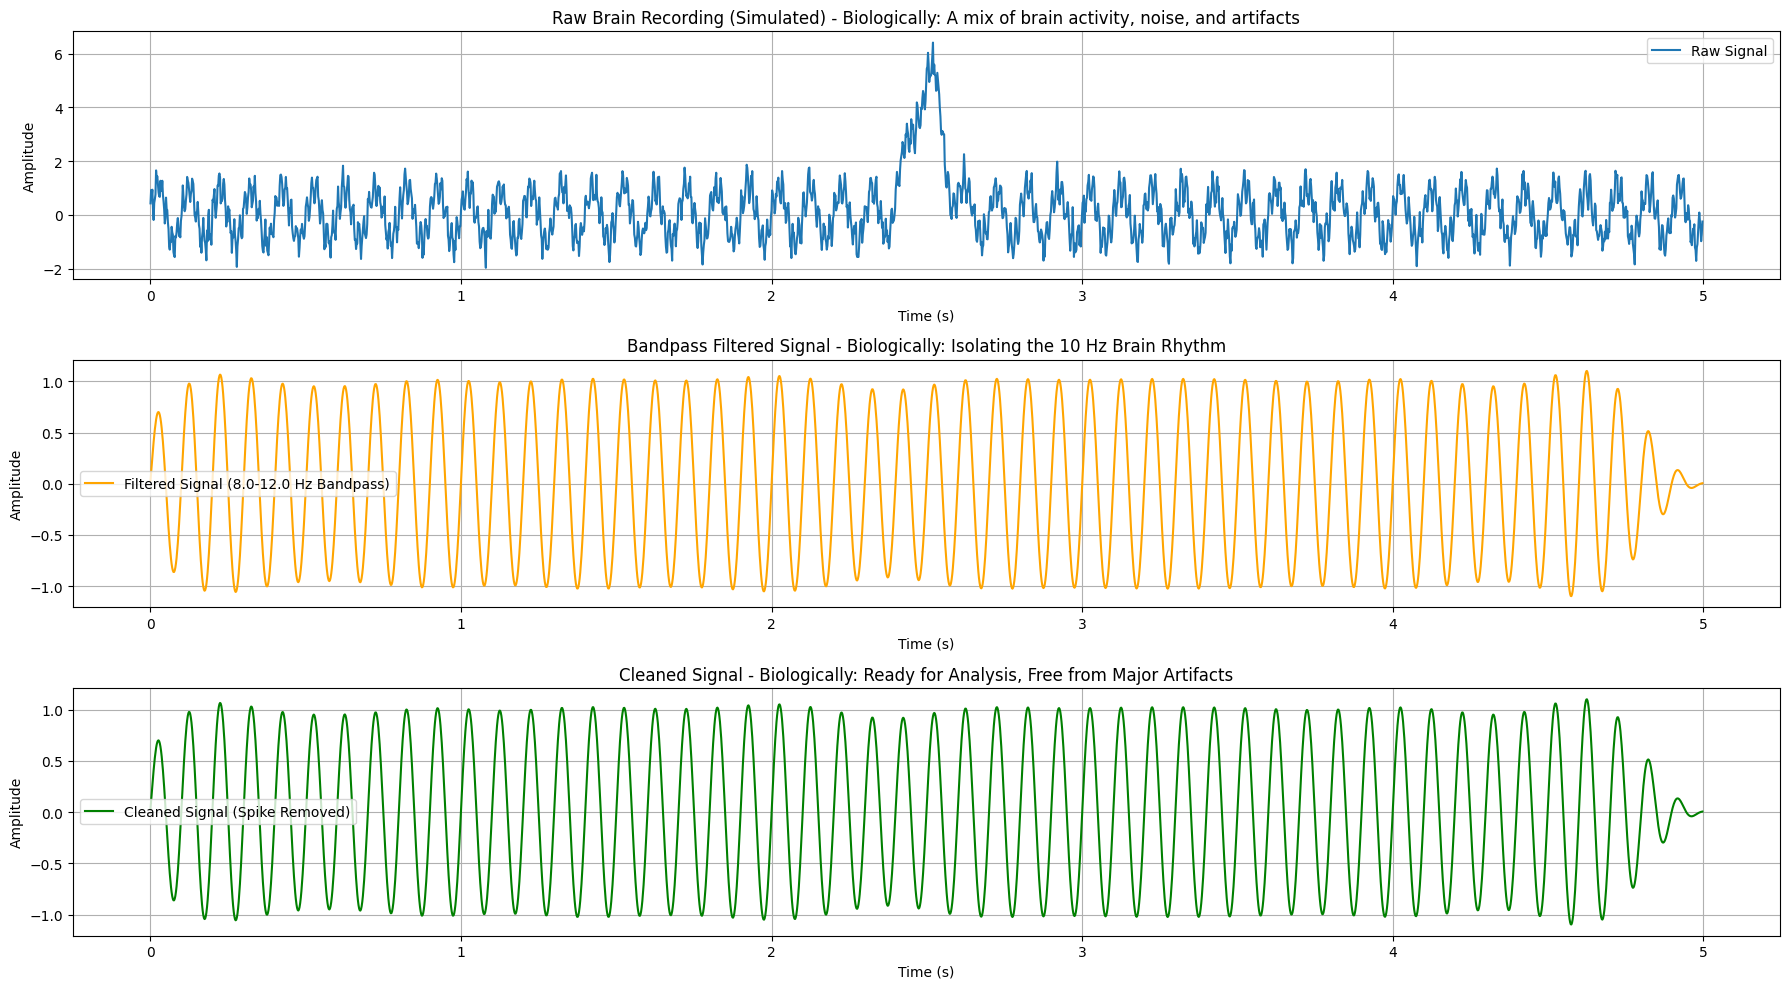

In [1]:
# 💻 Activity A.1 — Paste your AI-generated Signal Filtering code here:

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# 1. Generate 5 seconds of a simulated brain signal

# Define signal parameters
sampling_rate = 500  # measurements per second (Hz)
duration = 5       # seconds
num_samples = int(sampling_rate * duration)
t = np.linspace(0, duration, num_samples, endpoint=False)

# Simulate a realistic 10 Hz brain rhythm (e.g., Alpha waves)
# Alpha waves are prominent when relaxed and awake, often around 8-12 Hz.
brain_rhythm_freq = 10  # Hz
brain_rhythm = 1.0 * np.sin(2 * np.pi * brain_rhythm_freq * t)

# Simulate 60 Hz electrical interference from the power supply
# This is a common artifact in many recordings, especially in North America.
electrical_noise_freq = 60 # Hz
electrical_noise = 0.5 * np.sin(2 * np.pi * electrical_noise_freq * t + np.random.rand() * 2 * np.pi) # Adding phase randomization

# Simulate a sudden large spike (e.g., eye blink or muscle movement artifact)
# These are transient, high-amplitude events that can obscure brain activity.
spike_time = 2.5 # seconds into the recording
spike_width = 0.05 # seconds
spike_amplitude = 5.0
spike = spike_amplitude * np.exp(-(t - spike_time)**2 / (2 * spike_width**2))

# Combine all components to create the noisy brain recording
noisy_signal = brain_rhythm + electrical_noise + spike + 0.2 * np.random.randn(num_samples) # Adding some general random noise

# 2. Explain in a comment how the Nyquist rule determines what sampling rate is needed
# The Nyquist rule states that to accurately capture all frequency components of a signal,
# the sampling rate must be at least twice the highest frequency present in that signal.
# In this simulated signal, the highest frequency component we are interested in (or want to remove)
# is the 60 Hz electrical interference. According to Nyquist, our sampling rate should be at least
# 2 * 60 Hz = 120 Hz. Our chosen sampling rate of 500 Hz is well above this minimum (500 Hz > 120 Hz),
# so we can accurately represent both the 10 Hz brain rhythm and the 60 Hz noise without 'aliasing',
# where higher frequencies falsely appear as lower frequencies due to undersampling.

# 3. Apply a digital bandpass filter to isolate the 10 Hz brain rhythm
# A bandpass filter allows frequencies within a specific range to pass through
# while attenuating (reducing the amplitude of) frequencies outside that range.
# Biologically, we want to isolate the 10 Hz brain rhythm (e.g., alpha waves).
# Mathematically, we define a passband (e.g., 8 Hz to 12 Hz) to keep the alpha rhythm
# and remove both lower frequencies (like slow drifts) and higher frequencies (like 60 Hz noise).

lowcut = 8.0  # Hz (lower bound of our desired brain rhythm)
highcut = 12.0 # Hz (upper bound of our desired brain rhythm)

# Normalize cutoff frequencies to the Nyquist frequency (half the sampling rate)
nyquist = 0.5 * sampling_rate
low = lowcut / nyquist
high = highcut / nyquist

# Design the filter: Butterworth is a common type for its flat passband.
# `b` and `a` are the numerator and denominator polynomial coefficients of the filter.
# `order=4` is a good balance between sharpness of cutoff and filter stability.
b, a = butter(4, [low, high], btype='band')

# Apply the filter forward and backward to avoid phase distortion (filtfilt)
filtered_signal = filtfilt(b, a, noisy_signal)

# 4. Add a simple threshold detector that flags and removes the eye blink spike
# Eye blinks or muscle movements cause very large, transient deflections in the signal.
# A simple way to 'remove' them is to identify points above a certain amplitude threshold
# and then replace those points. Biologically, these are artifacts we want to ignore.
# Mathematically, we're using a threshold to detect outliers and then interpolating
# to create a smoother, more 'cleaned' signal where the artifact was.

cleaned_signal = np.copy(filtered_signal) # Start with the filtered signal
spike_threshold = 2.5 # Arbitrary threshold, tune based on spike amplitude

# Find indices where the signal exceeds the threshold (absolute value to catch positive and negative spikes)
spike_indices = np.where(np.abs(filtered_signal) > spike_threshold)[0]

# For simplicity, we'll replace the spike region with a linear interpolation.
# A more sophisticated approach might use spline interpolation or other artifact rejection methods.
if len(spike_indices) > 0:
    # Find the start and end of the largest continuous spike region for simpler interpolation
    # This is a simplification; a real scenario might have multiple spikes
    spike_start = spike_indices[0]
    spike_end = spike_indices[-1]

    # Define points just before and after the spike for interpolation
    pre_spike_idx = max(0, spike_start - int(0.1 * sampling_rate)) # A bit before the spike
    post_spike_idx = min(num_samples - 1, spike_end + int(0.1 * sampling_rate)) # A bit after the spike

    # Ensure pre and post indices are distinct and within bounds
    if pre_spike_idx >= post_spike_idx:
        # Fallback if the spike is at the beginning/end or too wide for simple interpolation
        cleaned_signal[spike_start:spike_end+1] = np.mean(filtered_signal)
    else:
        # Linear interpolation between the point before and after the detected spike region
        x = [t[pre_spike_idx], t[post_spike_idx]]
        y = [filtered_signal[pre_spike_idx], filtered_signal[post_spike_idx]]
        cleaned_signal[spike_start:spike_end+1] = np.interp(t[spike_start:spike_end+1], x, y)

# 5. Display plots of the raw signal, the filtered signal, and the cleaned signal side-by-side
plt.figure(figsize=(18, 10))

# Plot Raw Signal
plt.subplot(3, 1, 1)
plt.plot(t, noisy_signal, label='Raw Signal')
plt.title('Raw Brain Recording (Simulated) - Biologically: A mix of brain activity, noise, and artifacts')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

# Plot Filtered Signal (after bandpass)
plt.subplot(3, 1, 2)
plt.plot(t, filtered_signal, label=f'Filtered Signal ({lowcut}-{highcut} Hz Bandpass)', color='orange')
plt.title(f'Bandpass Filtered Signal - Biologically: Isolating the {brain_rhythm_freq} Hz Brain Rhythm')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

# Plot Cleaned Signal (after spike removal)
plt.subplot(3, 1, 3)
plt.plot(t, cleaned_signal, label='Cleaned Signal (Spike Removed)', color='green')
# Highlight where the spike was removed for visual clarity
spike_removed_plot_indices = np.where(np.abs(filtered_signal) > spike_threshold)[0]
if len(spike_removed_plot_indices) > 0:
    plt.scatter(t[spike_removed_plot_indices], cleaned_signal[spike_removed_plot_indices],
                color='red', marker='x', s=50, label='Removed Spike Region')

plt.title('Cleaned Signal - Biologically: Ready for Analysis, Free from Major Artifacts')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


### 🧭 Activity A.2 — Visualizing How Signals Change Over Time

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a neuroscience data visualization instructor. Write a Python script using SciPy and Matplotlib that shows how to create a time-frequency plot (spectrogram) of a brain signal. The script should:
> 1. Generate a signal that shifts from a slow rhythm (8 Hz, representing a resting brain state) for the first 2 seconds, then transitions to a faster rhythm (25 Hz, representing an active brain state) for the final 3 seconds.
> 2. Compute a spectrogram of this signal that shows how its frequency content changes over time.
> 3. Display the spectrogram with a color scale showing signal strength, with time on the horizontal axis and frequency on the vertical axis.
> Add plain-language comments explaining what a spectrogram reveals that a simple time-series plot cannot."

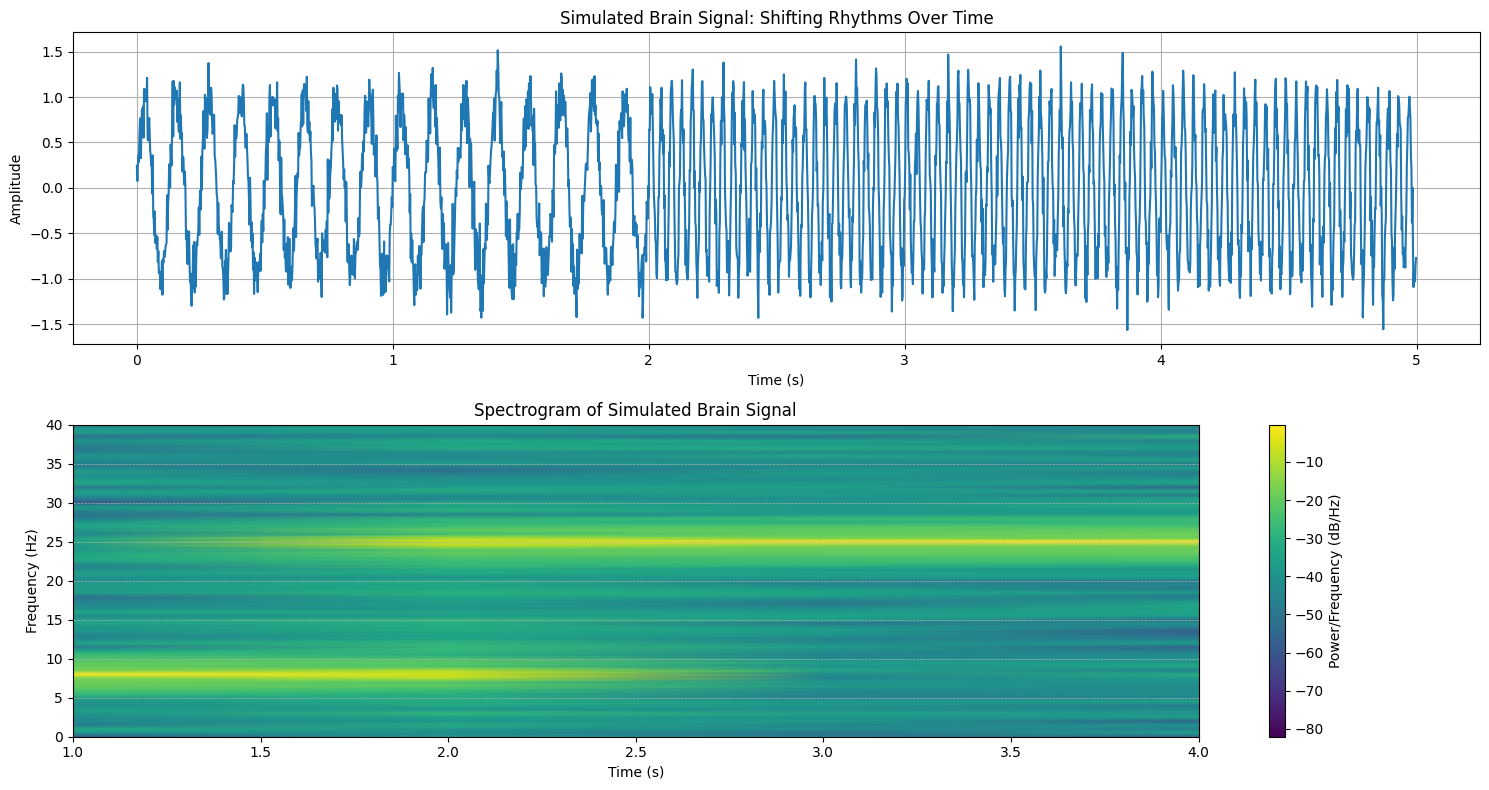

In [2]:
# 💻 Activity A.2 — Paste your AI-generated Spectrogram code here:

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# 1. Generate a signal that shifts from a slow rhythm to a faster rhythm

# Define common signal parameters
sampling_rate = 500  # measurements per second (Hz)

# Part 1: Slow rhythm (8 Hz) for the first 2 seconds (resting brain state)
duration_1 = 2       # seconds
num_samples_1 = int(sampling_rate * duration_1)
t1 = np.linspace(0, duration_1, num_samples_1, endpoint=False)
freq_slow = 8        # Hz (e.g., Alpha waves, associated with relaxed wakefulness)
signal_slow = 1.0 * np.sin(2 * np.pi * freq_slow * t1)

# Part 2: Faster rhythm (25 Hz) for the final 3 seconds (active brain state)
duration_2 = 3       # seconds
num_samples_2 = int(sampling_rate * duration_2)
t2 = np.linspace(duration_1, duration_1 + duration_2, num_samples_2, endpoint=False)
freq_fast = 25       # Hz (e.g., Beta or Gamma waves, associated with active cognition)
signal_fast = 1.0 * np.sin(2 * np.pi * freq_fast * t2)

# Combine the two parts of the signal
t = np.concatenate((t1, t2))
signal = np.concatenate((signal_slow, signal_fast))

# Add some random noise for realism
signal += 0.2 * np.random.randn(len(signal))

# Plot the generated time-series signal to see the amplitude changes
plt.figure(figsize=(15, 8))
plt.subplot(2, 1, 1)
plt.plot(t, signal)
plt.title('Simulated Brain Signal: Shifting Rhythms Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# 2. Compute a spectrogram of this signal
# A spectrogram breaks down the signal into its constituent frequencies over short, overlapping time windows.
# This allows us to see how the frequency content evolves, rather than just the amplitude changes.
# NFFT: The number of data points used in each FFT (Fast Fourier Transform) block.
# noverlap: The number of points overlapping between segments.
# fs: The sampling frequency of the signal.
f, times, Sxx = spectrogram(signal, fs=sampling_rate, nperseg=sampling_rate*2, noverlap=sampling_rate)

# 3. Display the spectrogram with a color scale showing signal strength
plt.subplot(2, 1, 2)
plt.pcolormesh(times, f, 10 * np.log10(Sxx), shading='gouraud') # 10*log10(Sxx) converts power to dB
plt.title('Spectrogram of Simulated Brain Signal')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.ylim([0, 40]) # Limit y-axis to relevant brain frequencies
plt.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Plain-language comments explaining what a spectrogram reveals that a simple time-series plot cannot:
# A simple time-series plot (like the top plot above) shows you the amplitude of the signal changing over time.
# You can see if the signal gets stronger or weaker, or if there are sudden spikes.
# However, it's very difficult to discern specific frequencies or how they change.

# For example, in our simulated signal, just by looking at the top plot, it's hard to tell that for the first
# two seconds there's a dominant 8 Hz rhythm and then it switches to a 25 Hz rhythm.

# A spectrogram (the bottom plot) is like slicing the signal into many tiny time windows and performing a
# frequency analysis (like a Fourier Transform) on each slice. It then plots these frequency analyses side-by-side
# over time.

# This allows us to clearly see:
# - Which frequencies are present at any given moment (vertical axis).
# - How strong those frequencies are (color intensity).
# - How these frequencies change over the entire duration of the recording (horizontal axis).
# So, a spectrogram reveals the 'rhythmic fingerprint' of the brain activity, showing its dynamic spectral content,
# which is crucial for understanding brain states like resting vs. active, sleep stages, or cognitive engagement.

### ✍️ Part A Reflection
*Double-click this cell to write your response.*

* **What I observed:** Looking at the filtered outputs from Activity A.1, what happened to the 60 Hz noise and the blink spike? Did the filter affect the brain rhythm you were trying to preserve?
* **Connecting to key concepts:** Activities A.1 and A.2 demonstrate **Concepts 15, 18, 19, and 21** from your Reference Guide. Explain in plain language what a spectrogram shows compared to a simple plot of voltage over time.

---

## 💻 Part B: Writing Workflows That Handle Problems Gracefully
### Topic: Error Handling and Protecting Your Original Data

This section introduces two principles that make research workflows more reliable and reproducible: handling unexpected errors without crashing, and never overwriting your original data.

### 🧭 Activity B.1 — Building a Workflow That Does Not Crash

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a research software reliability instructor. Write a Python script that demonstrates how to build an analysis workflow that handles unexpected data problems gracefully, without crashing the entire analysis. The script should:
> 1. Create a dataset of measurements that intentionally includes some problematic values — such as a zero where a division will be performed, or a missing value.
> 2. Write an analysis loop that processes each measurement, using an error-handling structure (try/except/finally) to catch and log any problems it encounters, rather than stopping immediately.
> 3. Demonstrate that when one measurement causes a problem, the workflow logs what went wrong and continues processing the remaining measurements.
> 4. Show clearly that the original dataset was not modified — the results are saved to a new, separate output.
> Use plain-language comments explaining why this approach is important for long analysis runs on large datasets."

In [3]:
# 💻 Activity B.1 — Paste your AI-generated Error Handling code here:

import numpy as np
import pandas as pd # Using pandas for structured data, good for representing research measurements

# 1. Create a dataset of measurements that intentionally includes some problematic values
# In real-world research, data might come from sensors, participant responses, or simulations.
# Here, we simulate a dataset where each 'measurement' has a 'value' and a 'divisor'.
# Some values are intentionally problematic to demonstrate robust error handling.
dataset = [
    {'id': 'Meas001', 'value': 10.0, 'divisor': 2.0},
    {'id': 'Meas002', 'value': 15.0, 'divisor': 3.0},
    {'id': 'Meas003', 'value': 20.0, 'divisor': 0.0},  # Problem: Division by zero
    {'id': 'Meas004', 'value': 25.0, 'divisor': 5.0},
    {'id': 'Meas005', 'value': np.nan, 'divisor': 2.5}, # Problem: Missing value (np.nan)
    {'id': 'Meas006', 'value': 30.0, 'divisor': 6.0},
    {'id': 'Meas007', 'value': None, 'divisor': 1.5},  # Problem: Missing value (None)
    {'id': 'Meas008', 'value': 40.0, 'divisor': 8.0}
]

# Display the original dataset to show it's intact later
print("Original Dataset:")
print(pd.DataFrame(dataset))
print("\n" + "-"*30 + "\n")

# Prepare containers for processed results and error logs
processed_results = []
error_logs = []

# 2. Write an analysis loop with an error-handling structure (try/except/finally)
# 3. Demonstrate that when one measurement causes a problem, the workflow logs what went wrong

print("Starting analysis loop...")
for i, measurement in enumerate(dataset):
    result = None
    log_entry = {
        'measurement_id': measurement['id'] if 'id' in measurement else f'Index{i}',
        'status': 'processed',
        'error_message': None
    }

    try:
        current_value = measurement['value']
        current_divisor = measurement['divisor']

        # Check for missing values before attempting calculation
        if current_value is None or np.isnan(current_value):
            raise ValueError("Missing 'value' for calculation")
        if current_divisor is None or np.isnan(current_divisor):
            raise ValueError("Missing 'divisor' for calculation")

        # Perform a hypothetical calculation (e.g., division)
        calculated_output = current_value / current_divisor
        result = {'id': measurement['id'], 'output': calculated_output}

    except ZeroDivisionError as e:
        log_entry['status'] = 'failed'
        log_entry['error_message'] = f"Calculation error: Division by zero. Details: {e}"
        print(f"  ⚠️ Error for {log_entry['measurement_id']}: {log_entry['error_message']}")

    except TypeError as e:
        log_entry['status'] = 'failed'
        log_entry['error_message'] = f"Data type error: Cannot perform operation with non-numeric type. Details: {e}"
        print(f"  ⚠️ Error for {log_entry['measurement_id']}: {log_entry['error_message']}")

    except ValueError as e:
        log_entry['status'] = 'failed'
        log_entry['error_message'] = f"Data validation error: {e}. Details: {e}"
        print(f"  ⚠️ Error for {log_entry['measurement_id']}: {log_entry['error_message']}")

    except Exception as e:
        # Catch any other unexpected errors
        log_entry['status'] = 'failed'
        log_entry['error_message'] = f"An unexpected error occurred: {type(e).__name__} - {e}"
        print(f"  ⚠️ Unexpected Error for {log_entry['measurement_id']}: {log_entry['error_message']}")

    finally:
        # The 'finally' block always executes, whether an error occurred or not.
        # This is a good place for cleanup or ensuring certain operations happen.
        # Here, we append the result (or None if failed) and the log entry.
        processed_results.append(result) # result will be None if an error prevented calculation
        error_logs.append(log_entry)
        print(f"  ✅ Finished processing {log_entry['measurement_id']}. Continuing to next measurement...")

print("\nAnalysis loop completed.")
print("\n" + "-"*30 + "\n")

# 4. Show clearly that the original dataset was not modified
# The 'dataset' variable remains exactly as it was initialized.
print("Original Dataset (unmodified):")
print(pd.DataFrame(dataset))
print("\n" + "-"*30 + "\n")

print("Processed Results (saved to a new output):")
# Filter out None values for display if you only want successful results
successful_results = [res for res in processed_results if res is not None]
print(pd.DataFrame(successful_results) if successful_results else "No successful results.")
print("\n" + "-"*30 + "\n")

print("Error Log (saved to a separate output):")
print(pd.DataFrame(error_logs))

# Plain-language comments explaining why this approach is important for long analysis runs on large datasets:
# Why is this approach important?
# Imagine you're analyzing brain signals from 100 participants, each with hours of data.
# Without robust error handling, if just one participant's file is corrupted, or a single data point
# causes a mathematical error (like division by zero), your entire analysis script would crash.
# This means:
#   - Lost Time: You'd have to manually find the error, fix it, and restart the whole process.
#   - Incomplete Results: You might only get partial results, or no results at all, for a long run.
#   - Difficulty in Debugging: Pinpointing the exact problem in vast datasets can be like finding a needle in a haystack.

# By using 'try/except/finally' blocks, we achieve several critical things:
#   1. Resilience: The analysis doesn't crash. It can gracefully handle individual data problems.
#   2. Completeness: Even if some data points are problematic, the rest of the valid data still gets processed.
#   3. Accountability: Errors are explicitly logged, telling us exactly *what* went wrong, *where*, and *why*.
#      This log becomes a valuable report for data quality control and debugging.
#   4. Data Integrity: The original raw data remains untouched. This is a golden rule in research!
#      If you accidentally mess up a calculation, you can always go back to the pristine original data.
#      Processed results and error logs are saved separately, maintaining a clear audit trail.

# In summary, this error-handling strategy makes your scientific workflows more reliable, efficient,
# and transparent, especially when dealing with the unpredictable nature of real-world research data.

Original Dataset:
        id  value  divisor
0  Meas001   10.0      2.0
1  Meas002   15.0      3.0
2  Meas003   20.0      0.0
3  Meas004   25.0      5.0
4  Meas005    NaN      2.5
5  Meas006   30.0      6.0
6  Meas007    NaN      1.5
7  Meas008   40.0      8.0

------------------------------

Starting analysis loop...
  ✅ Finished processing Meas001. Continuing to next measurement...
  ✅ Finished processing Meas002. Continuing to next measurement...
  ⚠️ Error for Meas003: Calculation error: Division by zero. Details: float division by zero
  ✅ Finished processing Meas003. Continuing to next measurement...
  ✅ Finished processing Meas004. Continuing to next measurement...
  ⚠️ Error for Meas005: Data validation error: Missing 'value' for calculation. Details: Missing 'value' for calculation
  ✅ Finished processing Meas005. Continuing to next measurement...
  ✅ Finished processing Meas006. Continuing to next measurement...
  ⚠️ Error for Meas007: Data validation error: Missing 'value' f

### ✍️ Part B Reflection
*Double-click this cell to write your response.*

* **What I observed:** What happened when the workflow encountered a problematic value? Did it stop, or did it continue? How was the problem recorded?
* **Connecting to key concepts:** Activity B.1 demonstrates **Concepts 45, 47, and 50** from your Reference Guide. Explain in plain language why a scientific workflow should never modify the original raw data files, even if it finds something wrong with them.

---

## 📑 What Comes Next

Notebook 5 introduces machine learning and pattern recognition — how computers can learn to identify behavioral states or intentions from brain signal patterns.


---

## 📖 Reference Guide: 50 Key Concepts for Neuroscience Workflows

Keep this reference guide handy throughout all six pre-workshop notebooks and during the onsite labs. These concepts form the foundation of the workshop's hands-on activities.

### 🧠 Neuroscience & Research Applications (Concepts 1–25)
1. **Brain-Machine Interface (BMI):** A system that connects the brain directly to an external device — bypassing damaged nerves or muscles — so that brain signals can control a robotic limb, cursor, or other tool.
2. **Non-Invasive (EEG) vs. Invasive (Intracortical) Sensors:** Scalp electrodes (EEG) are easy to use but pick up blurry, averaged signals through the skull. Implanted microelectrode arrays record from individual neurons with much greater precision, but require surgery.
3. **Signal Delay (Latency):** The time gap between a brain signal being recorded and a device responding to it. Delays longer than about 50–100 milliseconds feel unnatural to the user of a prosthetic device.
4. **Decoder:** A mathematical or statistical model that translates continuous brain signal patterns into a useful output — such as movement direction, cursor position, or speech intent.
5. **fMRI:** Functional Magnetic Resonance Imaging — a brain scanning method that measures blood oxygen levels as a stand-in for neural activity. When neurons become active, they consume more oxygen, causing a detectable change in the local blood signal.
6. **Voxel:** A small 3D cube of brain tissue in an fMRI image — the brain-imaging equivalent of a pixel. Each voxel contains millions of neurons.
7. **Head Movement Correction:** A processing step that aligns brain scan images across time, compensating for small movements the participant made during the recording session.
8. **Open-Loop vs. Closed-Loop Systems:** An open-loop device follows a fixed program regardless of what the user's brain is doing. A closed-loop device continuously reads incoming signals and adjusts its output in real time based on what it detects.
9. **Deep Brain Stimulation (DBS):** A treatment for conditions like Parkinson's disease in which a small implanted device delivers electrical pulses to specific brain regions to reduce tremor and improve movement.
10. **EMG (Electromyogram):** A recording of the electrical signals produced by muscles when they contract. Often used alongside brain recordings to verify whether a behavioral response actually occurred.
11. **Continuous Recordings vs. Event Markers:** A continuous recording captures an uninterrupted time series of measurements. Event markers are specific timestamps that label when something important happened — such as when a stimulus appeared or a button was pressed.
12. **Signal Drift:** The gradual change in a recorded signal over time, not due to the brain, but due to electrode movement, tissue changes, or electronic drift. Workflows need to account for this to keep analysis accurate over long sessions.
13. **Open Data Repositories:** Publicly accessible online archives (such as DANDI, OpenNeuro, or the Human Connectome Project) where researchers share their raw data so others can analyze or replicate their findings.
14. **Automated Data Download (API):** A method of downloading data directly inside a script using a standardized web link, rather than clicking through a website manually. This makes data access reproducible and audit-able.
15. **Artifact Removal:** The process of identifying and removing unwanted signals — such as electrical noise from the building, muscle movements, or eye blinks — from a raw brain recording before analysis.
16. **Downsampling:** Reducing the number of data points per second in a recording, to save memory and processing time, when the extra detail is not needed for the analysis.
17. **Standard Data Formats (BIDS):** A community-agreed system for naming and organizing brain imaging files so that any researcher or software tool can understand the structure without needing special instructions.
18. **Spectrogram:** A visual display showing how the frequency content of a signal changes over time — useful for seeing when the brain shifts between different rhythmic states such as sleep stages or attention levels.
19. **Nyquist Rule:** A fundamental rule of digital recording: to accurately capture a signal, you must record at least twice as fast as the highest frequency in that signal. Recording too slowly creates false patterns called aliasing.
20. **Local Field Potential (LFP):** An electrical recording that reflects the combined activity of a small cluster of nearby neurons — capturing the general activity level of a local brain region rather than individual cells.
21. **Signal Transfer Function:** A mathematical description of how an input signal is transformed into an output signal by a processing step — useful for predicting what a filter or decoder will do to any given input.
22. **Spike Sorting:** The process of separating a mixed electrical recording from multiple nearby neurons into individual neuron signals, based on the distinct shape of each neuron's electrical discharge.
23. **Machine Learning for Neural Decoding:** Using statistical learning algorithms to automatically find patterns in brain signal data that predict behavior, movement intent, or cognitive state.
24. **Sensory Feedback:** Sending information back to the user of a brain-machine interface — for example, delivering a gentle electrical sensation to the skin to simulate the feeling of touching an object with a prosthetic hand.
25. **Neural Plasticity:** The brain's ability to reorganize its connections over time. Relevant to BMI research because users can learn to control devices more accurately with practice as their brain adapts.

### 💻 Computing & Workflow Fundamentals (Concepts 26–50)
26. **Working Memory (RAM) vs. Permanent Storage:** RAM (working memory) holds data only while the computer is on — it is extremely fast but temporary. The hard drive stores files permanently but is much slower to access.
27. **Processor Core:** A single computing unit inside a central processor (CPU). Most modern computers have multiple cores, allowing several tasks to run at the same time.
28. **CPU vs. GPU:** A CPU handles complex, varied tasks one at a time across a few powerful cores. A GPU handles simple, repetitive tasks across thousands of smaller cores simultaneously — useful for image processing and machine learning.
29. **Memory Overflow:** What happens when a script tries to load more data into working memory (RAM) than the computer has available — causing the program to crash.
30. **Motherboard:** The main circuit board inside a computer that connects all the components — processor, memory, storage, and network — so they can communicate with each other.
31. **Processor Slowdown (Thermal Throttling):** When a processor gets too hot, it automatically slows itself down to prevent damage. This can cause unexpected slowdowns during long analysis runs.
32. **High-Speed Processor Cache:** A small, extremely fast memory area built directly into the processor, used to store frequently needed values so they do not have to be fetched from RAM repeatedly.
33. **Local vs. Cloud Computing:** Running your analysis on the computer in front of you (local) versus running it on a remote server accessed over the internet (cloud). Cloud computing allows access to much more memory and processing power.
34. **Temporary Cloud Workspace:** Cloud computing environments like Google Colab provide a temporary workspace that is automatically cleared when you close the session. Any files you need to keep must be saved to permanent storage before the session ends.
35. **Internet Speed as a Bottleneck:** When downloading large research datasets, the speed of your internet connection often limits how fast data can arrive — regardless of how fast your computer itself is.
36. **Organizing Code into Stages:** Separating a workflow into clearly defined, independent stages — such as one stage for loading data, one for analysis, and one for visualization — makes it much easier to find and fix problems.
37. **Whole Numbers vs. Decimal Numbers in Computing:** Computers store whole numbers (integers) very efficiently. Decimal numbers (floating-point) require more memory and processing time. Choosing the right type for your data can affect both speed and accuracy.
38. **Automated Data Access (API):** A standardized connection that allows one piece of software to request data or services from another automatically — for example, a script that downloads data from a research repository without any manual steps.
39. **Settings Files (JSON/YAML):** Lightweight text files used to store configuration settings, metadata, and parameters for a workflow — making it easy to share, reproduce, or adjust an analysis without changing the code itself.
40. **Processing Delay:** The time between when data arrives in your workflow and when your analysis produces a result. In real-time recording systems, keeping this delay short is critical.
41. **Keeping Stages Independent:** Designing a workflow so that the data analysis stage does not depend on the visualization stage, and vice versa. This means you can update or replace one stage without breaking the others.
42. **Text Files vs. Optimized Data Files:** Saving data as plain text (such as CSV) is easy to read in a spreadsheet but very slow for large datasets. Optimized formats (such as HDF5 or NumPy binary files) are much faster to load and take up less disk space.
43. **Simultaneous Processing (Parallel Computing):** Splitting a large task — such as analyzing 50 participants — into smaller chunks that run at the same time across multiple processor cores, rather than one after another.
44. **Hidden Configuration Settings:** Values that a workflow needs — such as access keys for a data repository — that are stored securely in the operating system rather than written directly into the code, to prevent accidental exposure.
45. **Software Libraries (Dependencies):** Pre-built collections of code (such as NumPy, SciPy, or scikit-learn) that provide ready-made tools for common tasks — so you do not have to write mathematical functions from scratch.
46. **Code Version Tracking (Git):** A system that records every change made to a set of code files over time, along with who made the change and when. This allows teams to collaborate and to restore earlier versions if something goes wrong.
47. **Error Handling:** Code that anticipates things going wrong — such as a missing file or a calculation that produces an undefined result — and responds gracefully rather than crashing the entire workflow.
48. **Data Array:** A structured list of numbers organized so that a computer can perform calculations on all of them efficiently — the basic building block of scientific data analysis.
49. **Data Backlog:** What happens when data arrives faster than your workflow can process it — causing a growing queue that eventually uses up available memory.
50. **Protecting Original Data:** A core rule of reproducible research: never modify your raw data files. Always write processed results to a new, separate file so the original record remains intact.


---

## ✅ Self-Check: What Did You Learn?

*Fill in the table below after completing both activities.*

| Concept Area | Concept Number | Where You Demonstrated It |
|---|---|---|
| Neuroscience | Concept 15 — Artifact removal | [ Enter Cell ID ] |
| Neuroscience | Concept 18 — Spectrogram | [ Enter Cell ID ] |
| Neuroscience | Concept 19 — Nyquist rule | [ Enter Cell ID ] |
| Computing | Concept 45 — Software libraries | [ Enter Cell ID ] |
| Computing | Concept 47 — Error handling | [ Enter Cell ID ] |
| Computing | Concept 50 — Protecting original data | [ Enter Cell ID ] |
